In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [6]:
import os
dataset_path = "../dataset"
files = os.listdir(dataset_path)
print(f"Files in the dataset foler: {files}")

Files in the dataset foler: ['hour.csv', 'Readme.txt', 'day.csv']


In [7]:
import pandas as pd

dataset_path = "../dataset/"

hour_path  = dataset_path + 'hour.csv'
day_path = dataset_path + 'day.csv'

df_hour = pd.read_csv(hour_path)

df_day = pd.read_csv(day_path)

print(f"shape : {df_day.shape}")

print(f"shape : {df_hour.shape}")

shape : (731, 16)
shape : (17379, 17)


In [31]:
import pandas as pd

dataset_path = "../dataset/"

hour_path = dataset_path + 'hour.csv'

df = df_hour.copy()

print(df.head())

print(df.tail())

print(df.dtypes)

print(df.columns.tolist())

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  
       instant      dteday  season  yr  mnth  hr  holiday  weekday  \
17374    17375  2012-12-31   

In [32]:
print("missing values are")
print(df_hour.isnull().sum())

missing values are
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [38]:
duplicates = df_hour.duplicated().sum()
print(f"number of duplicate rows :{duplicates}")

number of duplicate rows :0


In [23]:
print(df_hour[['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']].describe())

               temp         atemp           hum     windspeed        casual  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       0.496987      0.475775      0.627229      0.190098     35.676218   
std        0.192556      0.171850      0.192930      0.122340     49.305030   
min        0.020000      0.000000      0.000000      0.000000      0.000000   
25%        0.340000      0.333300      0.480000      0.104500      4.000000   
50%        0.500000      0.484800      0.630000      0.194000     17.000000   
75%        0.660000      0.621200      0.780000      0.253700     48.000000   
max        1.000000      1.000000      1.000000      0.850700    367.000000   

         registered           cnt  
count  17379.000000  17379.000000  
mean     153.786869    189.463088  
std      151.357286    181.387599  
min        0.000000      1.000000  
25%       34.000000     40.000000  
50%      115.000000    142.000000  
75%      220.000000    281.000000  


In [36]:
# check whitespaces
whitespace_found = False

string_cols = df_hour.select_dtypes(include=['object']).columns

for col in string_cols:
    has_spaces = df_hour[col].astype(str).str.strip().ne(df_hour[col].astype(str)).any()
    if has_spaces:
        print(f"Column '{col}' has white spaces")
        whitespace_found = True

empty_strings = (df_hour.astype(str).apply(lambda x: x.str.strip()) == '').sum()
empty_strings_detected = empty_strings[empty_strings > 0]

if not empty_strings_detected.empty:
    print("no blank spaces")
    print(empty_strings_detected)
    whitespace_found = True

if not whitespace_found:
    print("no whitespaces")

no whitespaces


In [37]:
# check text numbers
for col in df_hour.columns:
    internal_types = set(df_hour[col].apply(type))
    print(f"Column '{col}': Data Type = {df_hour[col].dtype} | Internal Types = {internal_types}")

Column 'instant': Data Type = int64 | Internal Types = {<class 'int'>}
Column 'dteday': Data Type = str | Internal Types = {<class 'str'>}
Column 'season': Data Type = int64 | Internal Types = {<class 'int'>}
Column 'yr': Data Type = int64 | Internal Types = {<class 'int'>}
Column 'mnth': Data Type = int64 | Internal Types = {<class 'int'>}
Column 'hr': Data Type = int64 | Internal Types = {<class 'int'>}
Column 'holiday': Data Type = int64 | Internal Types = {<class 'int'>}
Column 'weekday': Data Type = int64 | Internal Types = {<class 'int'>}
Column 'workingday': Data Type = int64 | Internal Types = {<class 'int'>}
Column 'weathersit': Data Type = int64 | Internal Types = {<class 'int'>}
Column 'temp': Data Type = float64 | Internal Types = {<class 'float'>}
Column 'atemp': Data Type = float64 | Internal Types = {<class 'float'>}
Column 'hum': Data Type = float64 | Internal Types = {<class 'float'>}
Column 'windspeed': Data Type = float64 | Internal Types = {<class 'float'>}
Column '

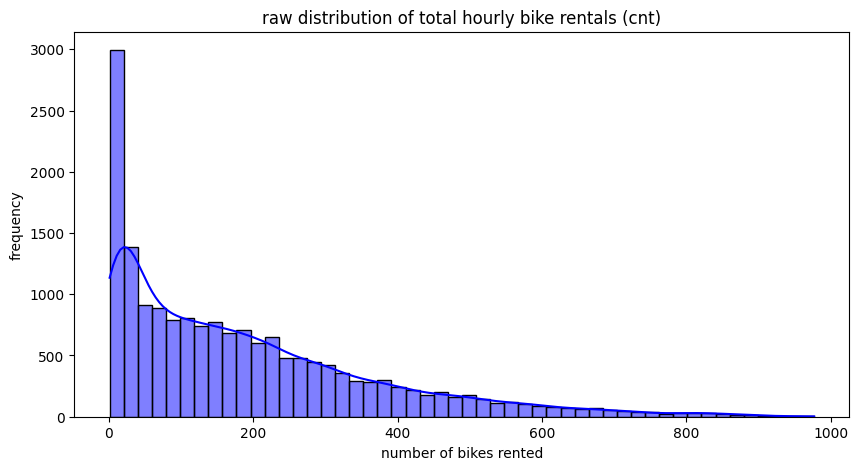

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(df_hour['cnt'], kde=True, color='blue', bins=50)
plt.title('raw distribution of total hourly bike rentals (cnt)')
plt.xlabel('number of bikes rented')
plt.ylabel('frequency')
plt.show()

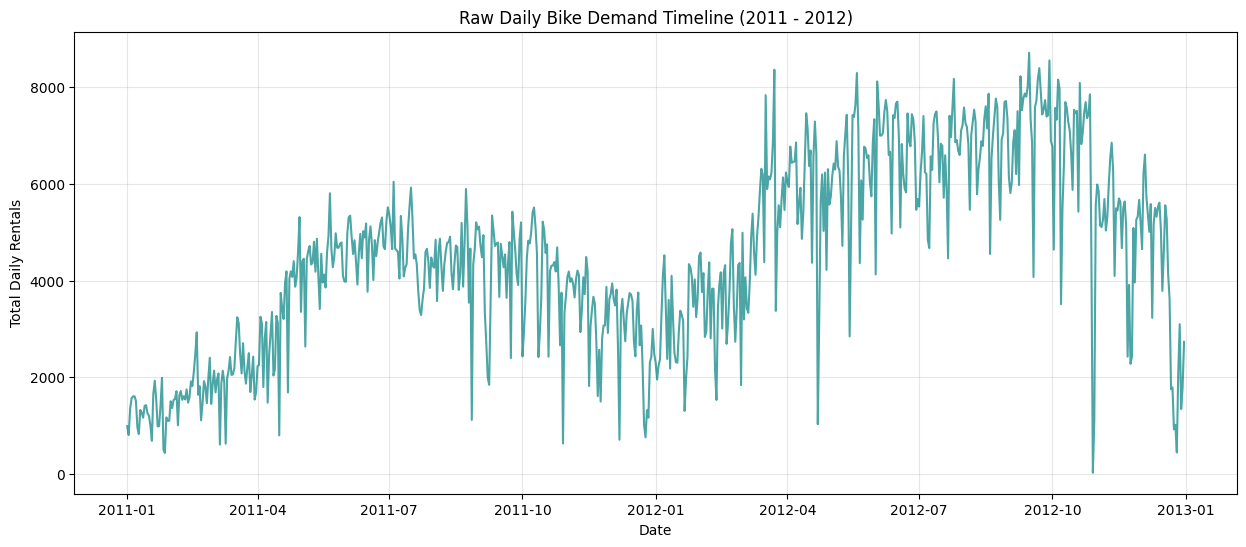

In [28]:
plt.figure(figsize=(15, 6))
plt.plot(pd.to_datetime(df_day['dteday']), df_day['cnt'], color='teal', alpha=0.7)
plt.title('Raw Daily Bike Demand Timeline (2011 - 2012)')
plt.xlabel('Date')
plt.ylabel('Total Daily Rentals')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
### Conver dteday to datetime

df['dteday'] = pd.to_datetime(df['dteday'])
print(f"Is data in chronological order? {df['dteday'].is_monotonic_increasing}")

Is data in chronological order? True


In [10]:
# convert to category
df['hr'] = df['hr'].astype('category')
df['mnth'] = df['mnth'].astype('category')
df['weekday'] = df['weekday'].astype('category')
print("Converted hr, mnth, weekday to category")

Converted hr, mnth, weekday to category


In [11]:
# create numeric copies
df['hr_num'] = df['hr'].cat.codes
df['mnth_num'] = df['mnth'].cat.codes + 1
df['weekday_num'] = df['weekday'].cat.codes
print("Numeric copies created")

Numeric copies created


In [12]:
## Check missing values
print(df.isnull().sum())

check = (df['casual'] + df['registered'] == df['cnt']).all()

print(f"Casual + registred = cn{check}")

print(f"\nSkewness: {df['cnt'].skew():.2f} (positive = right-skewed)")

instant        0
dteday         0
season         0
yr             0
mnth           0
hr             0
holiday        0
weekday        0
workingday     0
weathersit     0
temp           0
atemp          0
hum            0
windspeed      0
casual         0
registered     0
cnt            0
hr_num         0
mnth_num       0
weekday_num    0
dtype: int64
Casual + registred = cnTrue

Skewness: 1.28 (positive = right-skewed)


In [13]:
# Check current data types
print("Current data types:")
print(df[['hr', 'mnth', 'weekday']].dtypes)

Current data types:
hr         category
mnth       category
weekday    category
dtype: object


In [14]:
df['hour_sin'] = np.sin(2 * np.pi * df['hr_num'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hr_num'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['mnth_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['mnth_num'] / 12)
df['dow_sin'] = np.sin(2 * np.pi * df['weekday_num'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['weekday_num'] / 7)
print("Sin/cos features created")

Sin/cos features created


In [15]:
df['is_weekend'] = df['weekday_num'].isin([5, 6]).astype(int)
df['is_rush_hour'] = df['hr_num'].isin([7, 8, 9, 17, 18, 19]).astype(int)
df['is_night'] = df['hr_num'].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
print("Binary features created")

Binary features created


In [16]:
df_clean = df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)
print("Dropped leakage columns")

Dropped leakage columns


In [19]:
### split x and y
X = df_clean.drop('cnt', axis=1)
y = df_clean['cnt']

print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")
print(f"Features: {X.columns.tolist()}")

X Shape: (17379, 24)
y Shape: (17379,)
Features: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'hr_num', 'mnth_num', 'weekday_num', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_rush_hour', 'is_night']


In [21]:
# verify leakage
leakage_check = ['casual', 'registered', 'instant', 'dteday']
leakage_found = [col for col in leakage_check if col in X.columns]
print(f"Leakage columns in X {leakage_found}")

Leakage columns in X []
